# Telco Customer Churn Prediction Using ML

A telecom company is losing customers every month. This is called **customer churn** — when a customer stops using a service and moves to a competitor.

Losing customers is expensive. Acquiring a new customer costs **5 to 7 times more** than retaining an existing one. If the company can **predict which customers are likely to leave before they actually leave**, they can take **proactive action** — offer discounts, improve service, or reach out personally — and stop the churn before it happens.

This project builds a complete **Machine Learning Classification system** that:
- Predicts whether a customer will churn
- Explains WHY each customer is at risk (SHAP)
- Assigns a risk score from 0 to 100
- Recommends a specific retention action per customer
- Calculates the business value of the entire system


## Problem Statement

> Given customer information including demographics, subscribed services and account details, can we **accurately predict whether a customer will churn** — and use that prediction to build a **targeted, cost-effective retention strategy** that maximizes business revenue?


## Why Classification?

```
Target Variable = Churn = 1 or 0
We are predicting a CATEGORY not a number
This makes it a CLASSIFICATION problem
Since we have labeled data it is SUPERVISED LEARNING
Binary Classification = only 2 possible outputs (Yes/No)
```



## Key Challenge — Class Imbalance

```
No Churn : 5,163 customers (73.4%)
Churn    : 1,869 customers (26.6%)

The model sees far more No Churn examples.
It learns to predict No Churn most of the time.
High accuracy but poor recall on actual churners.

Fix Applied: SMOTE (Synthetic Minority Oversampling)
After SMOTE: 50% No Churn / 50% Churn (balanced)
```

## Models & Techniques Used

### Classification Models

| Model | Type | AUC Score | Recall |
|-------|------|-----------|--------|
| **Logistic Regression** | Linear | **0.8397** | **0.7859** |
| AdaBoost | Boosting | 0.8338 | 0.7623 |
| CatBoost | Boosting | 0.8278 | 0.5867 |
| LightGBM | Boosting | 0.8248 | 0.5760 |
| Random Forest | Bagging | 0.8164 | 0.5739 |
| XGBoost | Boosting | 0.8147 | 0.5760 |
| KNN | Instance | 0.7531 | 0.7259 |
| Decision Tree | Tree | 0.6717 | 0.5653 |

### Advanced Techniques

| Technique | Purpose | Result |
|-----------|---------|--------|
| SMOTE | Fix class imbalance | 73/27 → 50/50 |
| Stratified K-Fold | Reliable evaluation | 5-fold CV |
| RandomizedSearchCV | Hyperparameter tuning | RF + XGB |
| SHAP Values | Explain predictions | Top features found |
| Voting Ensemble | Combine top 3 models | AUC=0.8388 |
| Stacking Ensemble | Meta-learning | AUC=0.8202 |
| Learning Curves | Bias-variance check | RF=overfit, LR=good |
| Threshold Tuning | Optimize cutoff | F1=0.40, Biz=0.05 |
| ImbPipeline | Production deployment | No data leakage |


In [1]:
# STEP 1: INSTALL & IMPORT ALL LIBRARIES

!pip install xgboost catboost lightgbm imbalanced-learn shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    cohen_kappa_score,
    f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [2]:
# STEP 2: LOAD DATASET

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded from URL")
except:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded from upload")

# Standardize all column names to lowercase
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded from upload

Shape: (7043, 21)
Columns: ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']

First 5 rows:
   customerid  gender  seniorcitizen partner dependents  tenure phoneservice  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      multiplelines internetservice onlin

In [3]:
# STEP 3: DATA CLEANING

print(f"Shape before: {df.shape}")

df['totalcharges'] = pd.to_numeric(
    df['totalcharges'], errors='coerce'
)
nulls = df['totalcharges'].isnull().sum()
print(f"Null values in totalcharges: {nulls}")

df.dropna(inplace=True)
df.drop('customerid', axis=1, inplace=True)

df['churn'] = (df['churn'] == 'Yes').astype(int)

print(f"Shape after:  {df.shape}")
print(f"\nChurn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate:     {df['churn'].mean()*100:.1f}%")
print(f"Retention Rate: {(1-df['churn'].mean())*100:.1f}%")

Shape before: (7043, 21)
Null values in totalcharges: 11
Shape after:  (7032, 20)

Churn Distribution:
churn
0    5163
1    1869
Name: count, dtype: int64

Churn Rate:     26.6%
Retention Rate: 73.4%


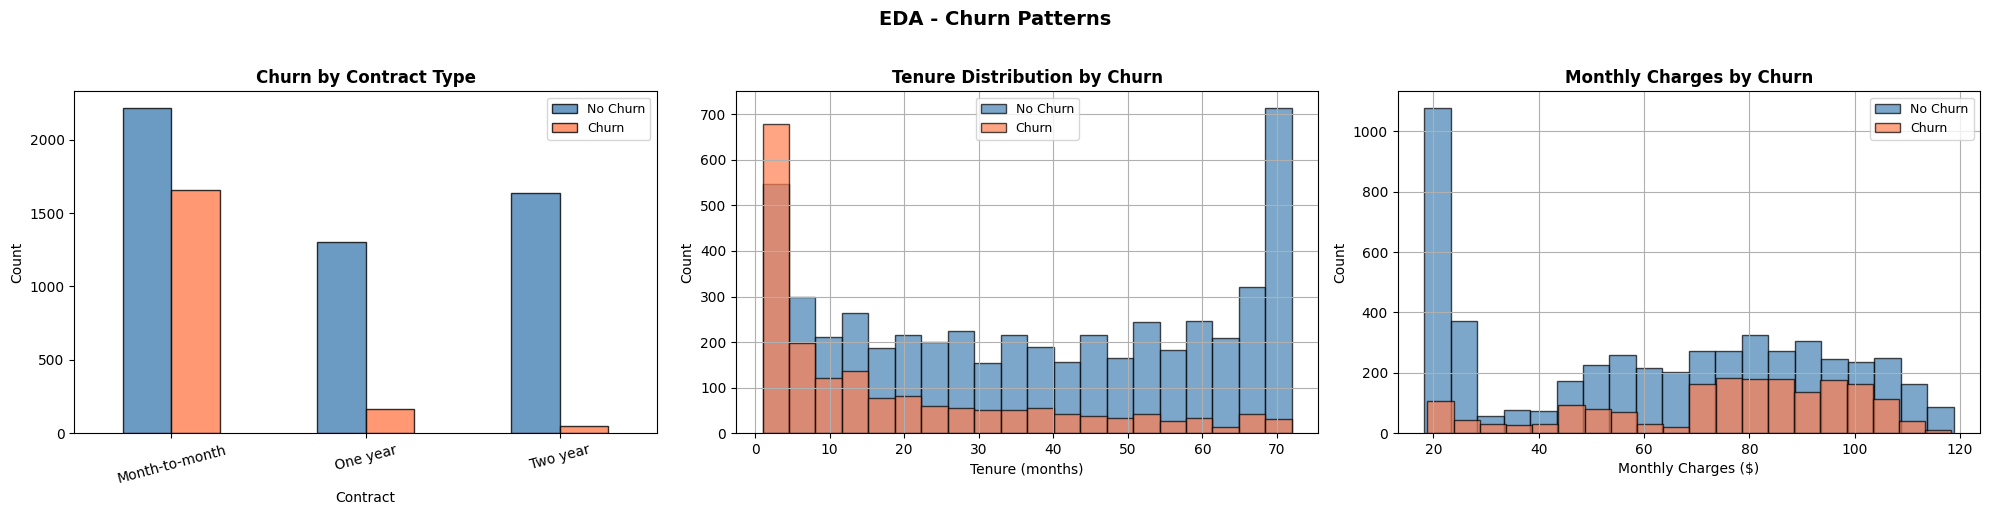

In [4]:
# STEP 4: EDA

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

contract_churn = df.groupby(
    ['contract', 'churn']
).size().unstack()
contract_churn.plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'coral'],
    edgecolor='black', alpha=0.8
)
axes[0].set_title('Churn by Contract Type',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['No Churn', 'Churn'], fontsize=9)

df[df['churn']==0]['tenure'].hist(
    ax=axes[1], bins=20, alpha=0.7,
    color='steelblue', label='No Churn',
    edgecolor='black'
)
df[df['churn']==1]['tenure'].hist(
    ax=axes[1], bins=20, alpha=0.7,
    color='coral', label='Churn',
    edgecolor='black'
)
axes[1].set_title('Tenure Distribution by Churn',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure (months)', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].legend(fontsize=9)

df[df['churn']==0]['monthlycharges'].hist(
    ax=axes[2], bins=20, alpha=0.7,
    color='steelblue', label='No Churn',
    edgecolor='black'
)
df[df['churn']==1]['monthlycharges'].hist(
    ax=axes[2], bins=20, alpha=0.7,
    color='coral', label='Churn',
    edgecolor='black'
)
axes[2].set_title('Monthly Charges by Churn',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Monthly Charges ($)', fontsize=10)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].legend(fontsize=9)

plt.suptitle('EDA - Churn Patterns',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# STEP 5: FEATURE ENGINEERING

df_fe = df.copy()

# 1. Tenure group
df_fe['tenure_group'] = pd.cut(
    df_fe['tenure'],
    bins=[0, 12, 36, 72],
    labels=['Short', 'Medium', 'Long']
).astype(str)

# 2. Charges ratio
df_fe['charges_ratio'] = (
    df_fe['totalcharges'] / (df_fe['tenure'] + 1)
).round(2)

# 3. High value flag
charge_75 = df_fe['monthlycharges'].quantile(0.75)
df_fe['is_high_value'] = (
    df_fe['monthlycharges'] > charge_75
).astype(int)

# 4. Number of services
service_cols = [
    'phoneservice', 'multiplelines',
    'internetservice', 'onlinesecurity',
    'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]
df_fe['num_services'] = df_fe[service_cols].apply(
    lambda row: sum(
        1 for v in row
        if v in ['Yes', 'DSL', 'Fiber optic']
    ), axis=1
)

# 5. Senior no support
df_fe['senior_no_support'] = (
    (df_fe['seniorcitizen'] == 1) &
    (df_fe['techsupport'] == 'No')
).astype(int)

# 6. New high charges
charge_med = df_fe['monthlycharges'].median()
df_fe['new_high_charges'] = (
    (df_fe['tenure'] < 12) &
    (df_fe['monthlycharges'] > charge_med)
).astype(int)

new_feats = [
    'tenure_group', 'charges_ratio', 'is_high_value',
    'num_services', 'senior_no_support', 'new_high_charges'
]

print("New features created:")
for f in new_feats:
    print(f"  + {f}")

print(f"\nChurn rate by Tenure Group:")
print(df_fe.groupby('tenure_group')['churn'].mean().round(3))

print(f"\nChurn rate by Num Services:")
print(df_fe.groupby('num_services')['churn'].mean().round(3))

nhc = df_fe[df_fe['new_high_charges']==1]['churn'].mean()
print(f"\nNew High Charges churn rate: {nhc*100:.1f}%")
print(f"Overall churn rate:          26.6%")

New features created:
  + tenure_group
  + charges_ratio
  + is_high_value
  + num_services
  + senior_no_support
  + new_high_charges

Churn rate by Tenure Group:
tenure_group
Long      0.119
Medium    0.255
Short     0.477
Name: churn, dtype: float64

Churn rate by Num Services:
num_services
1    0.110
2    0.310
3    0.449
4    0.365
5    0.314
6    0.256
7    0.226
8    0.124
9    0.053
Name: churn, dtype: float64

New High Charges churn rate: 69.8%
Overall churn rate:          26.6%


In [6]:
# STEP 6: PREPROCESSING

cat_cols   = df_fe.select_dtypes(
    include='object'
).columns.tolist()
df_encoded = pd.get_dummies(
    df_fe, columns=cat_cols, drop_first=True
)

X = df_encoded.drop('churn', axis=1)
Y = df_encoded['churn']

print(f"Features: {X.shape[1]}")
print(f"Records:  {X.shape[0]}")

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25,
    random_state=42, stratify=Y
)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train churn: {Y_train.mean()*100:.1f}%")
print(f"Test churn:  {Y_test.mean()*100:.1f}%")
print("stratify=Y maintains same ratio in both splits")

sc             = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

print("\nStandardScaler applied")
print("  fit_transform on train (learns mean & std)")
print("  transform only on test (applies same scale)")

Features: 37
Records:  7032

Train: 5274 | Test: 1758
Train churn: 26.6%
Test churn:  26.6%
stratify=Y maintains same ratio in both splits

StandardScaler applied
  fit_transform on train (learns mean & std)
  transform only on test (applies same scale)


Before SMOTE:
  No Churn: 3872 (73.4%)
  Churn:    1402 (26.6%)

After SMOTE:
  No Churn: 3872 (50.0%)
  Churn:    3872 (50.0%)

Training records: 7744 (was 5274)
Synthetic added:  2470


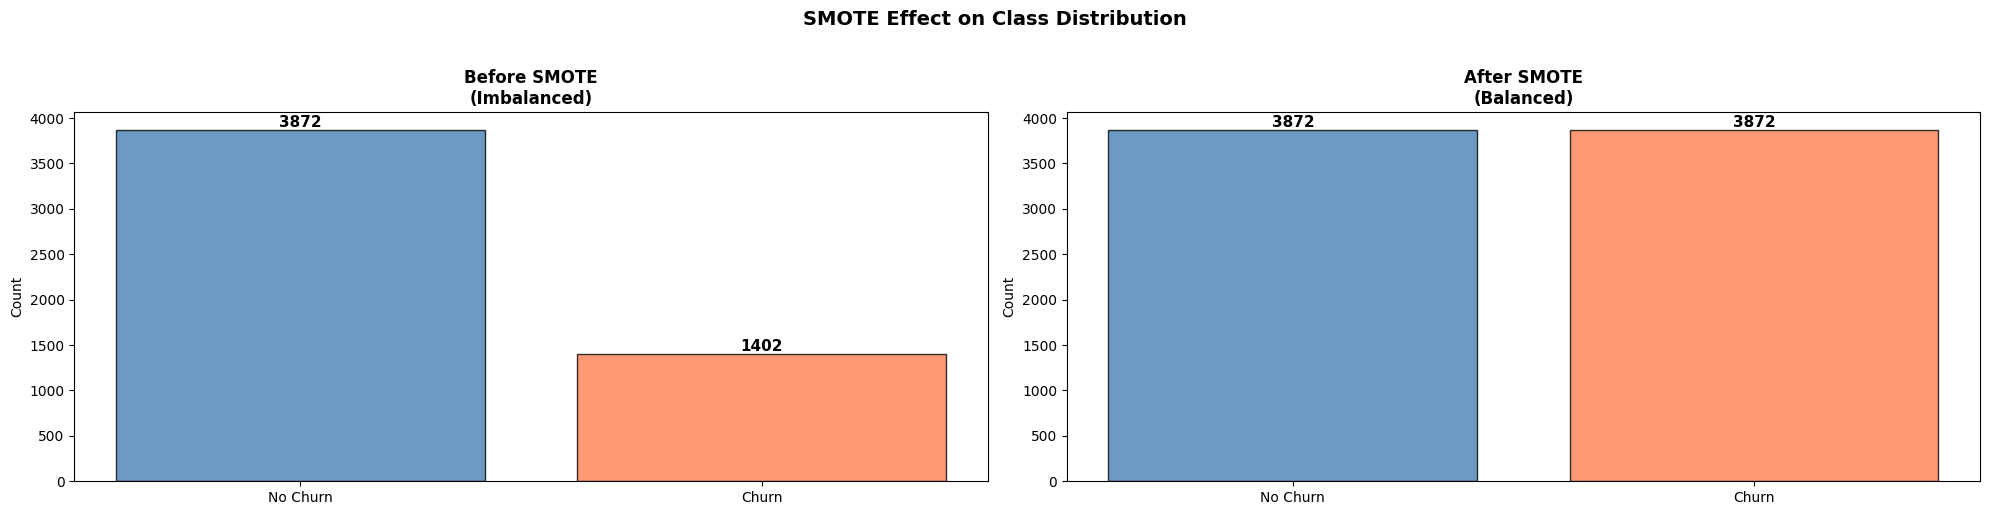

In [7]:
# STEP 7: SMOTE

print(f"Before SMOTE:")
print(f"  No Churn: {(Y_train==0).sum()} "
      f"({(Y_train==0).mean()*100:.1f}%)")
print(f"  Churn:    {(Y_train==1).sum()} "
      f"({(Y_train==1).mean()*100:.1f}%)")

smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(
    X_train_scaled, Y_train
)

print(f"\nAfter SMOTE:")
print(f"  No Churn: {(Y_train_sm==0).sum()} "
      f"({(Y_train_sm==0).mean()*100:.1f}%)")
print(f"  Churn:    {(Y_train_sm==1).sum()} "
      f"({(Y_train_sm==1).mean()*100:.1f}%)")
print(f"\nTraining records: {len(X_train_sm)} "
      f"(was {len(X_train_scaled)})")
print(f"Synthetic added:  "
      f"{len(X_train_sm) - len(X_train_scaled)}")

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

before = pd.Series(Y_train).value_counts()
after  = pd.Series(Y_train_sm).value_counts()

for ax, data, title in zip(
    axes,
    [before, after],
    ['Before SMOTE\n(Imbalanced)', 'After SMOTE\n(Balanced)']
):
    bars = ax.bar(
        ['No Churn', 'Churn'], data.values,
        color=['steelblue', 'coral'],
        edgecolor='black', alpha=0.8
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10)
    for bar, v in zip(bars, data.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            v + 30, str(v),
            ha='center', fontsize=11, fontweight='bold'
        )

plt.suptitle('SMOTE Effect on Class Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Running 5-Fold CV...
-------------------------------------------------------
  Logistic Regression   : F1=0.7880 (+/- 0.0070)
  Random Forest         : F1=0.8598 (+/- 0.0078)
  AdaBoost              : F1=0.8251 (+/- 0.0073)
  XGBoost               : F1=0.8528 (+/- 0.0091)
  LightGBM              : F1=0.8583 (+/- 0.0060)

CV Summary:
                     Mean F1  Std F1  Min F1  Max F1
Random Forest         0.8598  0.0078  0.8497  0.8725
LightGBM              0.8583  0.0060  0.8521  0.8680
XGBoost               0.8528  0.0091  0.8395  0.8655
AdaBoost              0.8251  0.0073  0.8177  0.8347
Logistic Regression   0.7880  0.0070  0.7764  0.7958


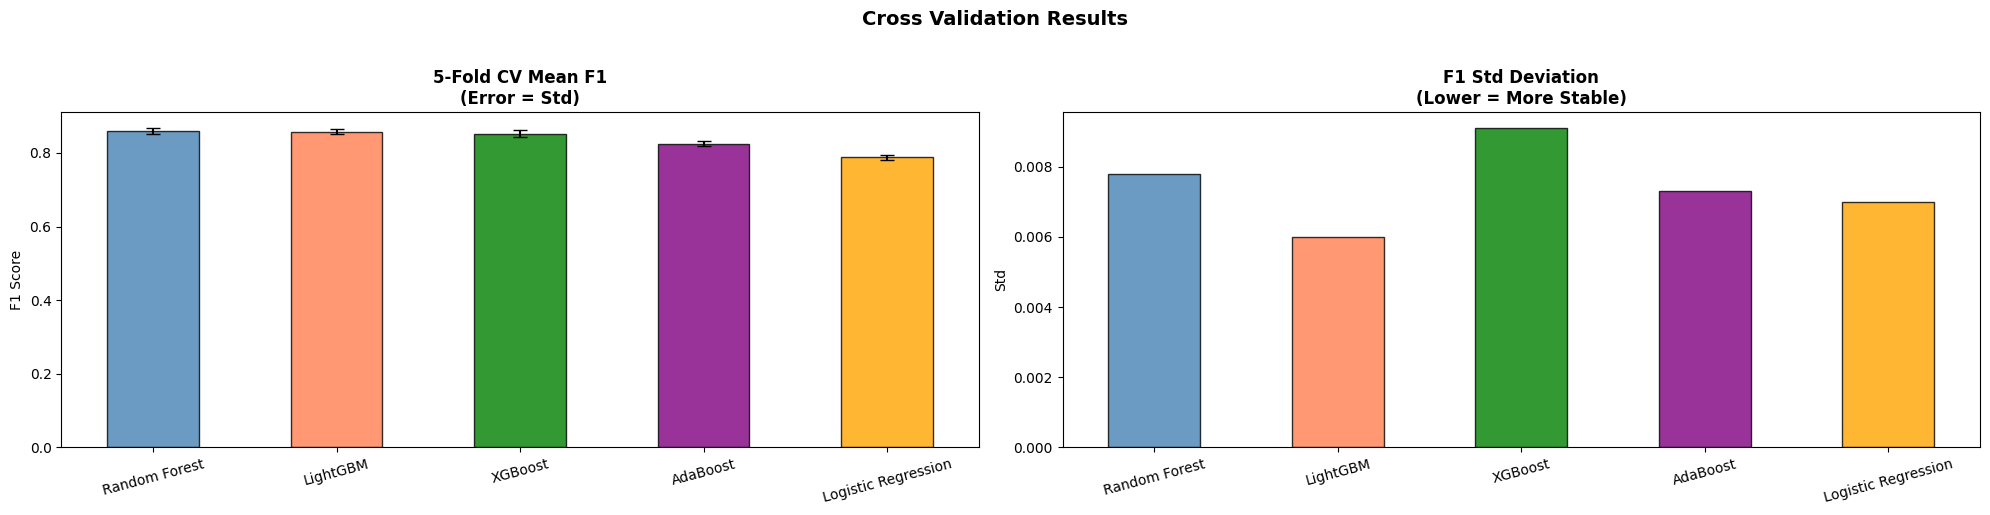

In [8]:
# STEP 8: STRATIFIED K-FOLD CV

skf = StratifiedKFold(n_splits=5, shuffle=True,
                      random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'Random Forest':       RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'AdaBoost':            AdaBoostClassifier(
        n_estimators=100, random_state=42
    ),
    'XGBoost':             XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0
    ),
    'LightGBM':            LGBMClassifier(
        n_estimators=100, random_state=42, verbose=-1
    ),
}

cv_results = {}
print("Running 5-Fold CV...")
print("-"*55)

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_sm, Y_train_sm,
        cv=skf, scoring='f1', n_jobs=-1
    )
    cv_results[name] = {
        'Mean F1': round(scores.mean(), 4),
        'Std F1':  round(scores.std(), 4),
        'Min F1':  round(scores.min(), 4),
        'Max F1':  round(scores.max(), 4)
    }
    print(f"  {name:<22}: "
          f"F1={scores.mean():.4f} "
          f"(+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).T.sort_values(
    'Mean F1', ascending=False
)
print("\nCV Summary:")
print(cv_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

cv_df['Mean F1'].plot(
    kind='bar', ax=axes[0],
    color=['steelblue','coral','green','purple','orange'],
    edgecolor='black', alpha=0.8,
    yerr=cv_df['Std F1'], capsize=5
)
axes[0].set_title('5-Fold CV Mean F1\n(Error = Std)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

cv_df['Std F1'].plot(
    kind='bar', ax=axes[1],
    color=['steelblue','coral','green','purple','orange'],
    edgecolor='black', alpha=0.8
)
axes[1].set_title('F1 Std Deviation\n(Lower = More Stable)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Cross Validation Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Training all models on SMOTE data...
-------------------------------------------------------
  Logistic Regression   : Acc=74.3%  AUC=0.8397  Recall=0.7859
  KNN                   : Acc=68.3%  AUC=0.7531  Recall=0.7259
  Decision Tree         : Acc=72.2%  AUC=0.6717  Recall=0.5653
  Random Forest         : Acc=77.9%  AUC=0.8164  Recall=0.5739
  AdaBoost              : Acc=75.6%  AUC=0.8338  Recall=0.7623
  XGBoost               : Acc=77.7%  AUC=0.8147  Recall=0.5760
  CatBoost              : Acc=78.3%  AUC=0.8278  Recall=0.5867
  LightGBM              : Acc=78.8%  AUC=0.8248  Recall=0.5760

Full Results Table:
                     Accuracy (%)  AUC Score  Precision  Recall  F1 Score   Kappa
Logistic Regression         74.35     0.8397     0.5111  0.7859    0.6194  0.4387
AdaBoost                    75.60     0.8338     0.5282  0.7623    0.6240  0.4520
CatBoost                    78.27     0.8278     0.5918  0.5867    0.5892  0.4415
LightGBM                    78.78     0.8248     0.605

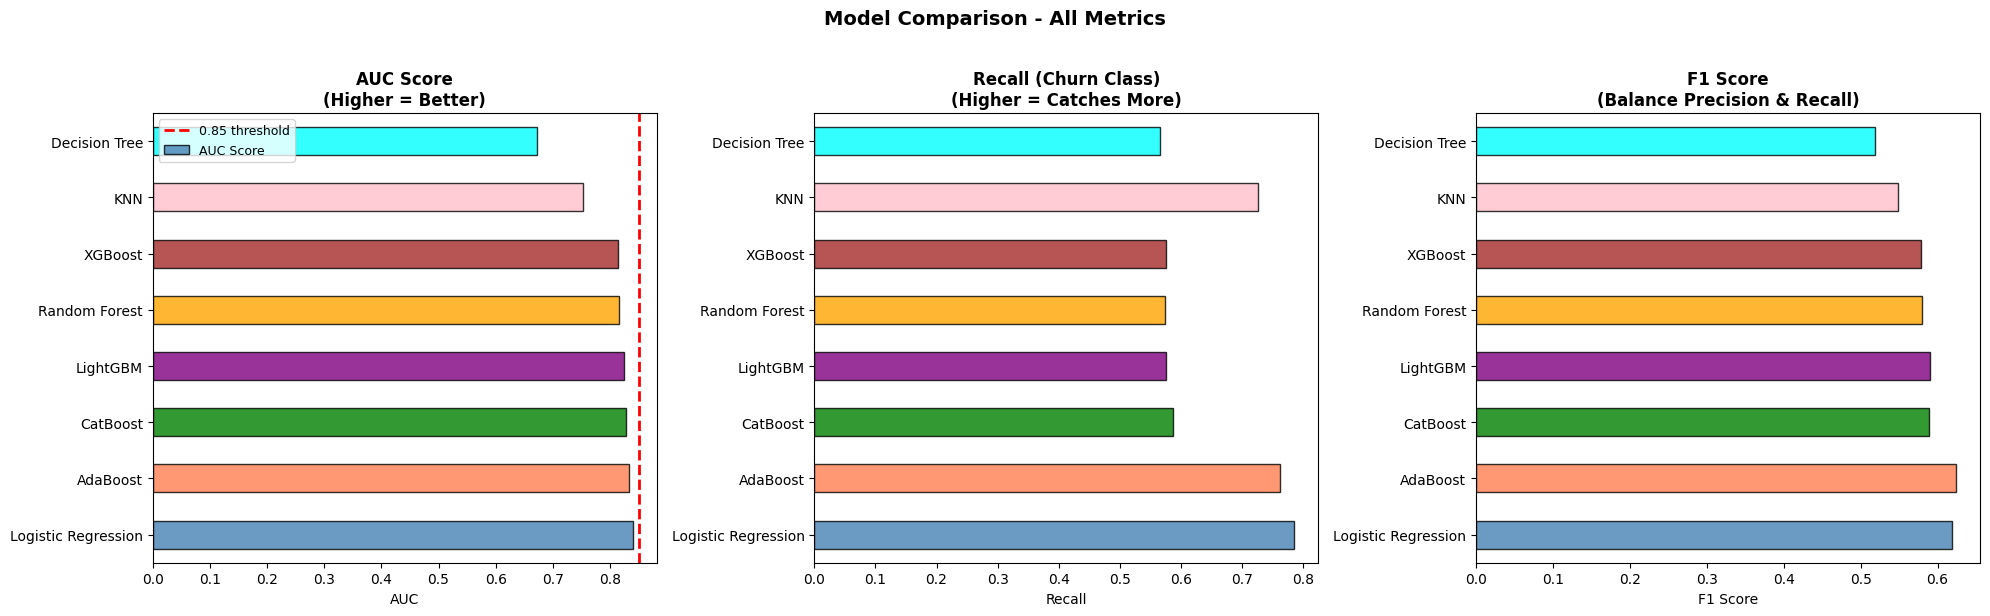

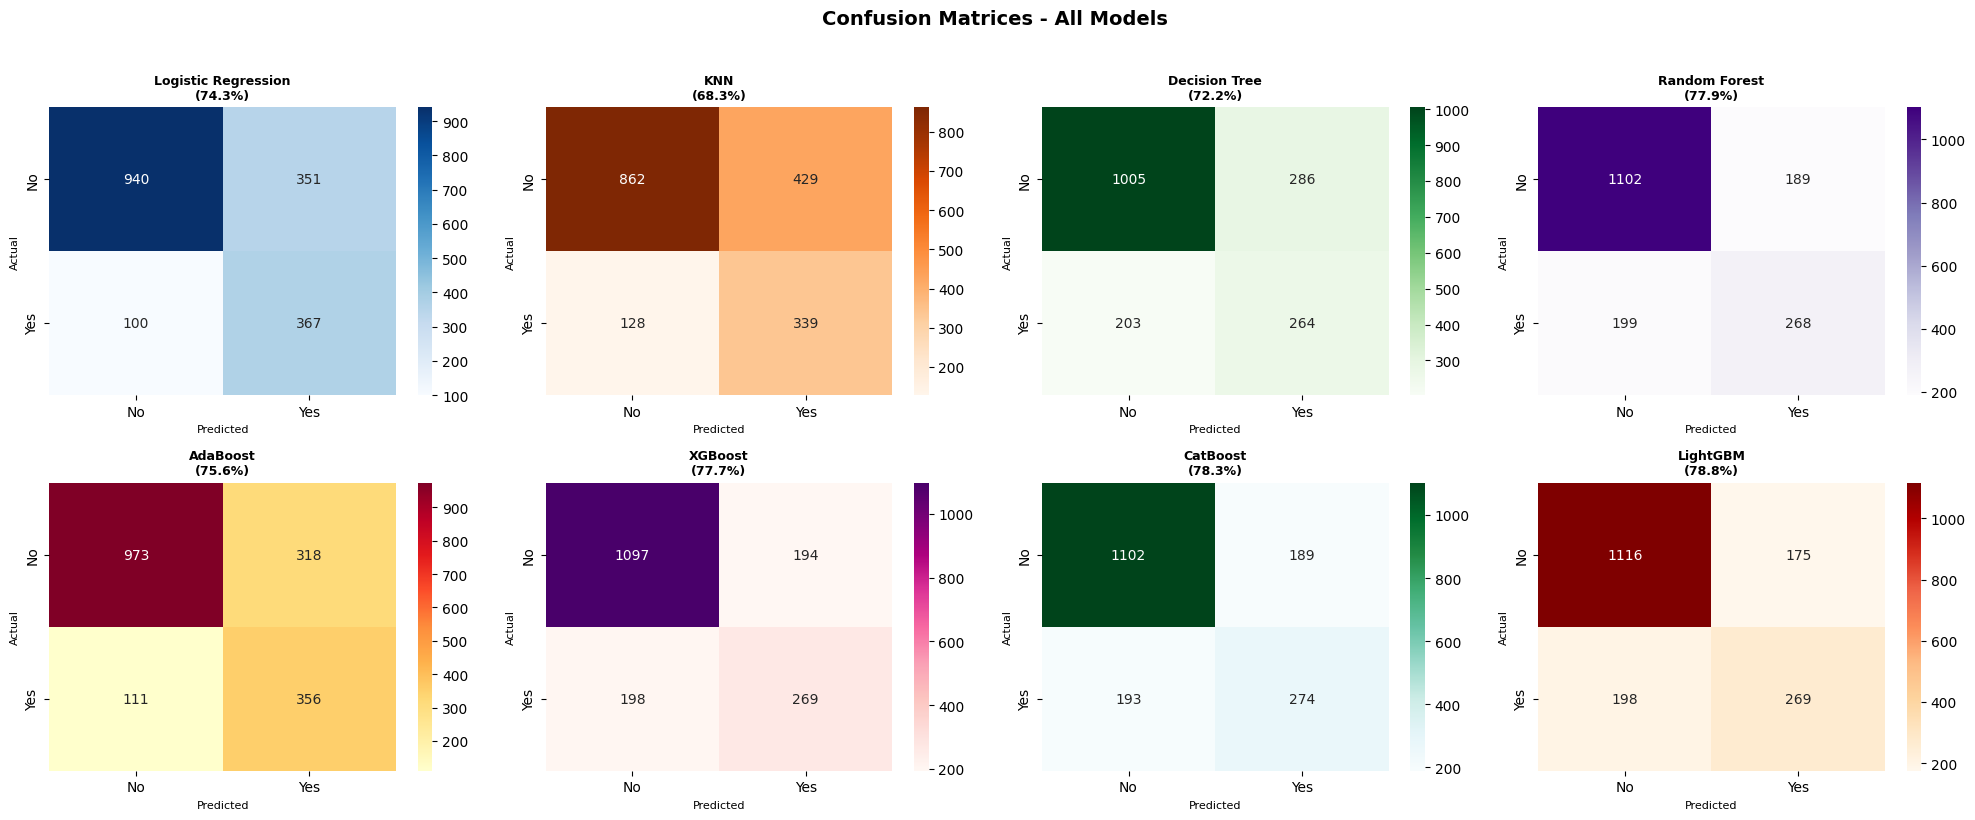

In [9]:
# STEP 9: TRAIN ALL 8 MODELS

all_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'AdaBoost':            AdaBoostClassifier(
        n_estimators=100, random_state=42
    ),
    'XGBoost':             XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0
    ),
    'CatBoost':            CatBoostClassifier(
        n_estimators=100, random_state=42, verbose=False
    ),
    'LightGBM':            LGBMClassifier(
        n_estimators=100, random_state=42, verbose=-1
    ),
}

model_results  = {}
trained_models = {}
all_preds      = {}
all_probs      = {}
all_cms        = {}

print("Training all models on SMOTE data...")
print("-"*55)

for name, model in all_models.items():
    model.fit(X_train_sm, Y_train_sm)
    trained_models[name] = model

    pred   = model.predict(X_test_scaled)
    prob   = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(
        Y_test, pred, output_dict=True
    )

    all_preds[name] = pred
    all_probs[name] = prob
    all_cms[name]   = confusion_matrix(Y_test, pred)

    model_results[name] = {
        'Accuracy (%)': round(
            accuracy_score(Y_test, pred) * 100, 2
        ),
        'AUC Score':    round(
            roc_auc_score(Y_test, prob), 4
        ),
        'Precision':    round(
            report['1']['precision'], 4
        ),
        'Recall':       round(
            report['1']['recall'], 4
        ),
        'F1 Score':     round(
            report['1']['f1-score'], 4
        ),
        'Kappa':        round(
            cohen_kappa_score(Y_test, pred), 4
        ),
    }
    print(f"  {name:<22}: "
          f"Acc={model_results[name]['Accuracy (%)']:.1f}%  "
          f"AUC={model_results[name]['AUC Score']:.4f}  "
          f"Recall={model_results[name]['Recall']:.4f}")

results_df = pd.DataFrame(model_results).T.sort_values(
    'AUC Score', ascending=False
)
print("\nFull Results Table:")
print(results_df.to_string())

best_name = results_df['AUC Score'].idxmax()
print(f"\nBest Model (by AUC): {best_name}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_colors = ['steelblue','coral','green','purple',
                'orange','brown','pink','cyan']

results_df['AUC Score'].plot(
    kind='barh', ax=axes[0],
    color=model_colors, edgecolor='black', alpha=0.8
)
axes[0].axvline(x=0.85, color='red',
                linestyle='--', linewidth=2,
                label='0.85 threshold')
axes[0].set_title('AUC Score\n(Higher = Better)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('AUC', fontsize=10)
axes[0].legend(fontsize=9)

results_df['Recall'].plot(
    kind='barh', ax=axes[1],
    color=model_colors, edgecolor='black', alpha=0.8
)
axes[1].set_title('Recall (Churn Class)\n(Higher = Catches More)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=10)

results_df['F1 Score'].plot(
    kind='barh', ax=axes[2],
    color=model_colors, edgecolor='black', alpha=0.8
)
axes[2].set_title('F1 Score\n(Balance Precision & Recall)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('F1 Score', fontsize=10)

plt.suptitle('Model Comparison - All Metrics',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes_flat  = axes.flatten()
cmaps_list = ['Blues','Oranges','Greens','Purples',
              'YlOrRd','RdPu','BuGn','OrRd']

for ax, (name, cm), cmap in zip(
    axes_flat, all_cms.items(), cmaps_list
):
    acc = model_results[name]['Accuracy (%)']
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=cmap, ax=ax,
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes']
    )
    ax.set_title(f'{name}\n({acc:.1f}%)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices - All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

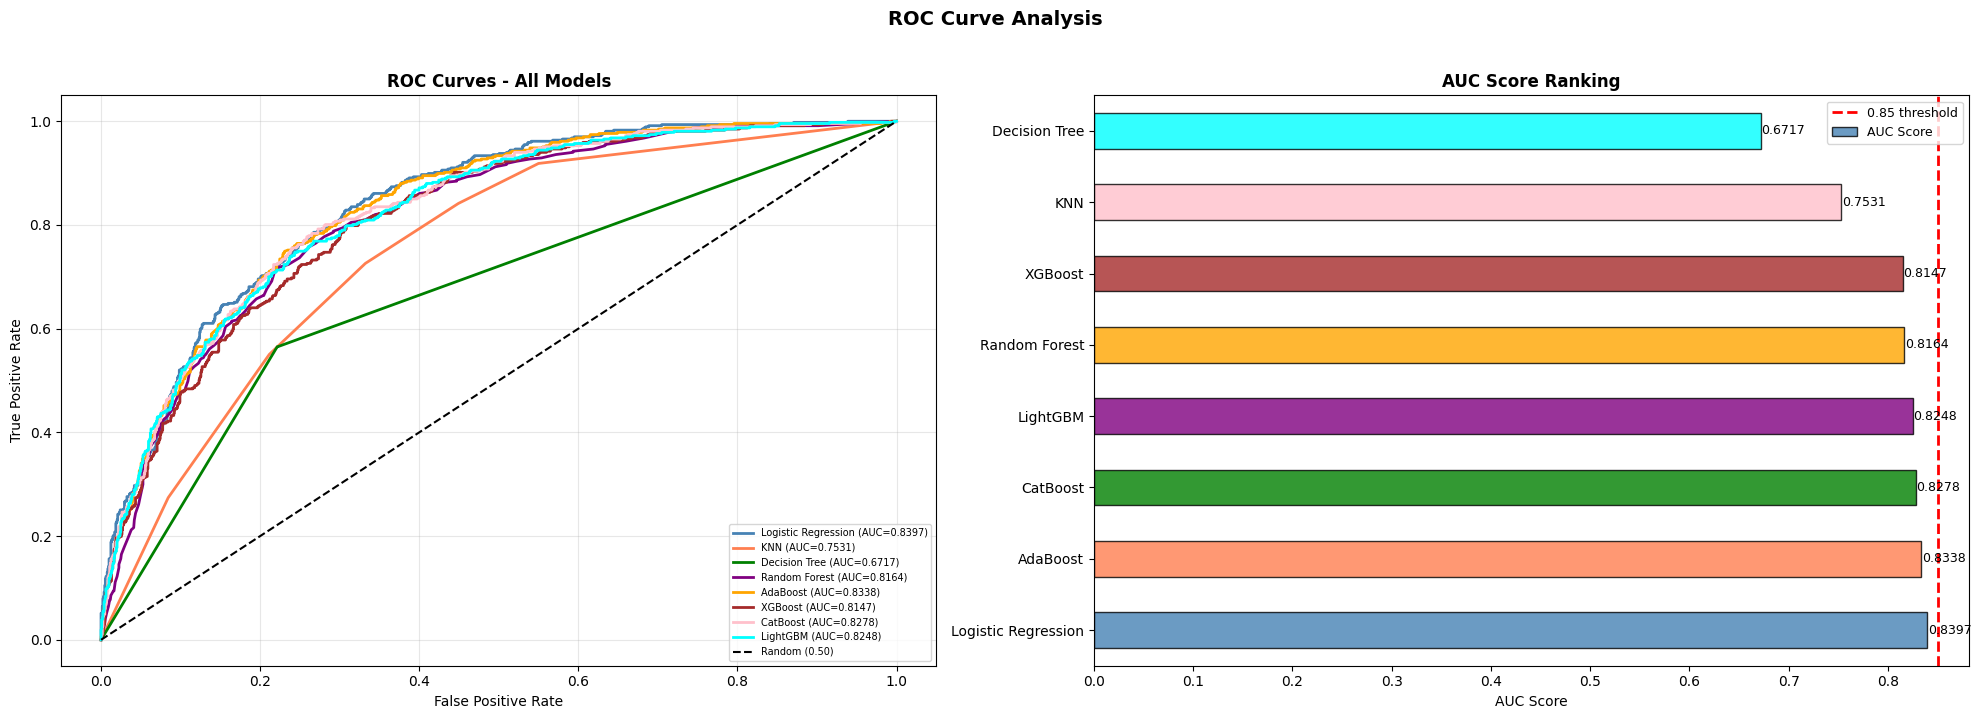

AUC Score Summary:
Logistic Regression    0.8397
AdaBoost               0.8338
CatBoost               0.8278
LightGBM               0.8248
Random Forest          0.8164
XGBoost                0.8147
KNN                    0.7531
Decision Tree          0.6717


In [10]:
# STEP 10: ROC CURVE & AUC

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for (name, prob), color in zip(
    all_probs.items(), model_colors
):
    fpr, tpr, _ = roc_curve(Y_test, prob)
    auc         = roc_auc_score(Y_test, prob)
    axes[0].plot(fpr, tpr, color=color,
                 linewidth=2,
                 label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1], [0,1], 'k--',
             linewidth=1.5, label='Random (0.50)')
axes[0].set_title('ROC Curves - All Models',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=10)
axes[0].set_ylabel('True Positive Rate', fontsize=10)
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(alpha=0.3)

results_df['AUC Score'].plot(
    kind='barh', ax=axes[1],
    color=model_colors[:len(results_df)],
    edgecolor='black', alpha=0.8
)
axes[1].axvline(x=0.85, color='red',
                linestyle='--', linewidth=2,
                label='0.85 threshold')
axes[1].set_title('AUC Score Ranking',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('AUC Score', fontsize=10)
axes[1].legend(fontsize=9)
for i, v in enumerate(results_df['AUC Score']):
    axes[1].text(v + 0.001, i, f'{v:.4f}',
                 va='center', fontsize=9)

plt.suptitle('ROC Curve Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("AUC Score Summary:")
print(results_df['AUC Score'].to_string())

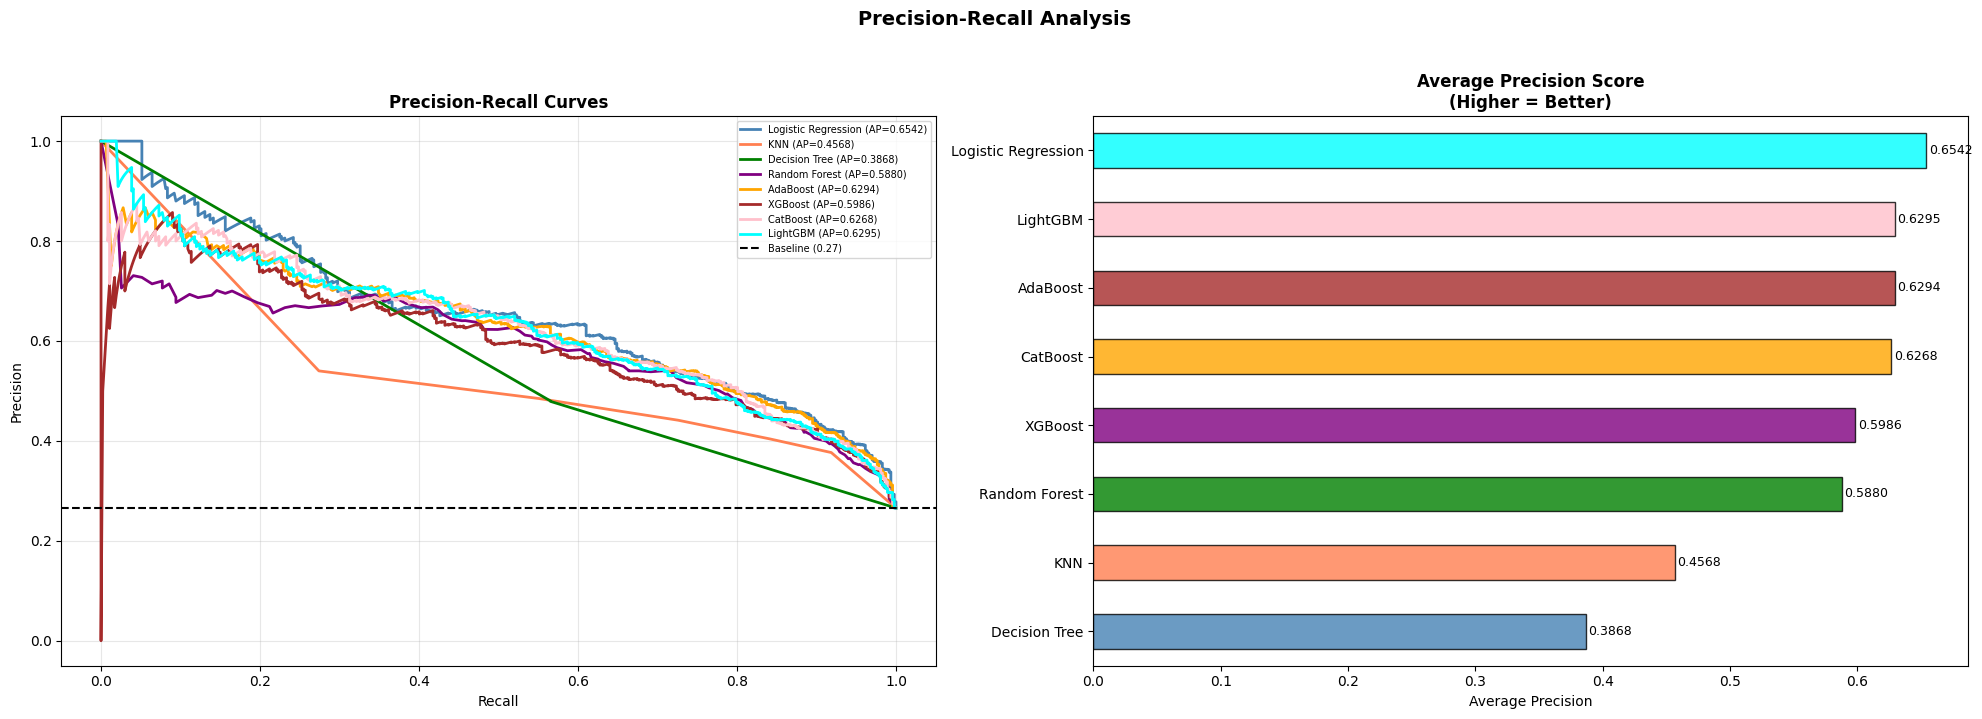

Average Precision Scores:
  Logistic Regression   : 0.6542
  LightGBM              : 0.6295
  AdaBoost              : 0.6294
  CatBoost              : 0.6268
  XGBoost               : 0.5986
  Random Forest         : 0.5880
  KNN                   : 0.4568
  Decision Tree         : 0.3868


In [11]:
# STEP 11: PRECISION-RECALL CURVE

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ap_scores = {}
for (name, prob), color in zip(
    all_probs.items(), model_colors
):
    prec, rec, _ = precision_recall_curve(Y_test, prob)
    ap = average_precision_score(Y_test, prob)
    ap_scores[name] = round(ap, 4)
    axes[0].plot(rec, prec, color=color,
                 linewidth=2,
                 label=f'{name} (AP={ap:.4f})')

baseline = Y_test.mean()
axes[0].axhline(y=baseline, color='black',
                linestyle='--', linewidth=1.5,
                label=f'Baseline ({baseline:.2f})')
axes[0].set_title('Precision-Recall Curves',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recall', fontsize=10)
axes[0].set_ylabel('Precision', fontsize=10)
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

ap_df = pd.Series(ap_scores).sort_values(ascending=True)
ap_df.plot(
    kind='barh', ax=axes[1],
    color=model_colors[:len(ap_df)],
    edgecolor='black', alpha=0.8
)
axes[1].set_title('Average Precision Score\n(Higher = Better)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Precision', fontsize=10)
for i, v in enumerate(ap_df.values):
    axes[1].text(v + 0.002, i, f'{v:.4f}',
                 va='center', fontsize=9)

plt.suptitle('Precision-Recall Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Average Precision Scores:")
for name, ap in sorted(
    ap_scores.items(), key=lambda x: x[1], reverse=True
):
    print(f"  {name:<22}: {ap:.4f}")

In [12]:
# STEP 12: HYPERPARAMETER TUNING

print("Tuning Random Forest...")
rf_param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=30, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_sm, Y_train_sm)
best_rf_tuned = rf_search.best_estimator_

Y_pred_tuned = best_rf_tuned.predict(X_test_scaled)
Y_prob_tuned = best_rf_tuned.predict_proba(
    X_test_scaled
)[:, 1]

tuned_acc = accuracy_score(Y_test, Y_pred_tuned)
tuned_auc = roc_auc_score(Y_test, Y_prob_tuned)
tuned_f1  = f1_score(Y_test, Y_pred_tuned)

print(f"\nBest RF Params: {rf_search.best_params_}")
print(f"\nBefore Tuning (RF):")
print(f"  AUC: {model_results['Random Forest']['AUC Score']:.4f}")
print(f"  F1:  {model_results['Random Forest']['F1 Score']:.4f}")
print(f"\nAfter Tuning (RF):")
print(f"  AUC: {tuned_auc:.4f}")
print(f"  F1:  {tuned_f1:.4f}")

print("\nTuning XGBoost...")
xgb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42, eval_metric='logloss',
        verbosity=0
    ),
    xgb_param_grid,
    n_iter=30, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_sm, Y_train_sm)
best_xgb_tuned = xgb_search.best_estimator_

Y_pred_xgb_t = best_xgb_tuned.predict(X_test_scaled)
Y_prob_xgb_t = best_xgb_tuned.predict_proba(
    X_test_scaled
)[:, 1]

print(f"Tuned XGB AUC: "
      f"{roc_auc_score(Y_test, Y_prob_xgb_t):.4f}")
print(f"Tuned XGB F1:  "
      f"{f1_score(Y_test, Y_pred_xgb_t):.4f}")

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None}

Before Tuning (RF):
  AUC: 0.8164
  F1:  0.5801

After Tuning (RF):
  AUC: 0.8202
  F1:  0.5830

Tuning XGBoost...
Tuned XGB AUC: 0.8364
Tuned XGB F1:  0.6232


F1-Optimized Threshold:       0.40
  → Use for INDIVIDUAL predictions
Business-Optimized Threshold: 0.05
  → Use for BULK marketing campaigns

Default (0.5) (t=0.50):
  Business Value: $11,470
  F1:             0.5830
  Recall:         0.5867
  TP=274 FP=199 FN=193

F1 Optimized (t=0.40):
  Business Value: $34,060
  F1:             0.6179
  Recall:         0.7152
  TP=334 FP=280 FN=133

Business Optimized (t=0.05):
  Business Value: $74,080
  F1:             0.4927
  Recall:         0.9700
  TP=453 FP=919 FN=14


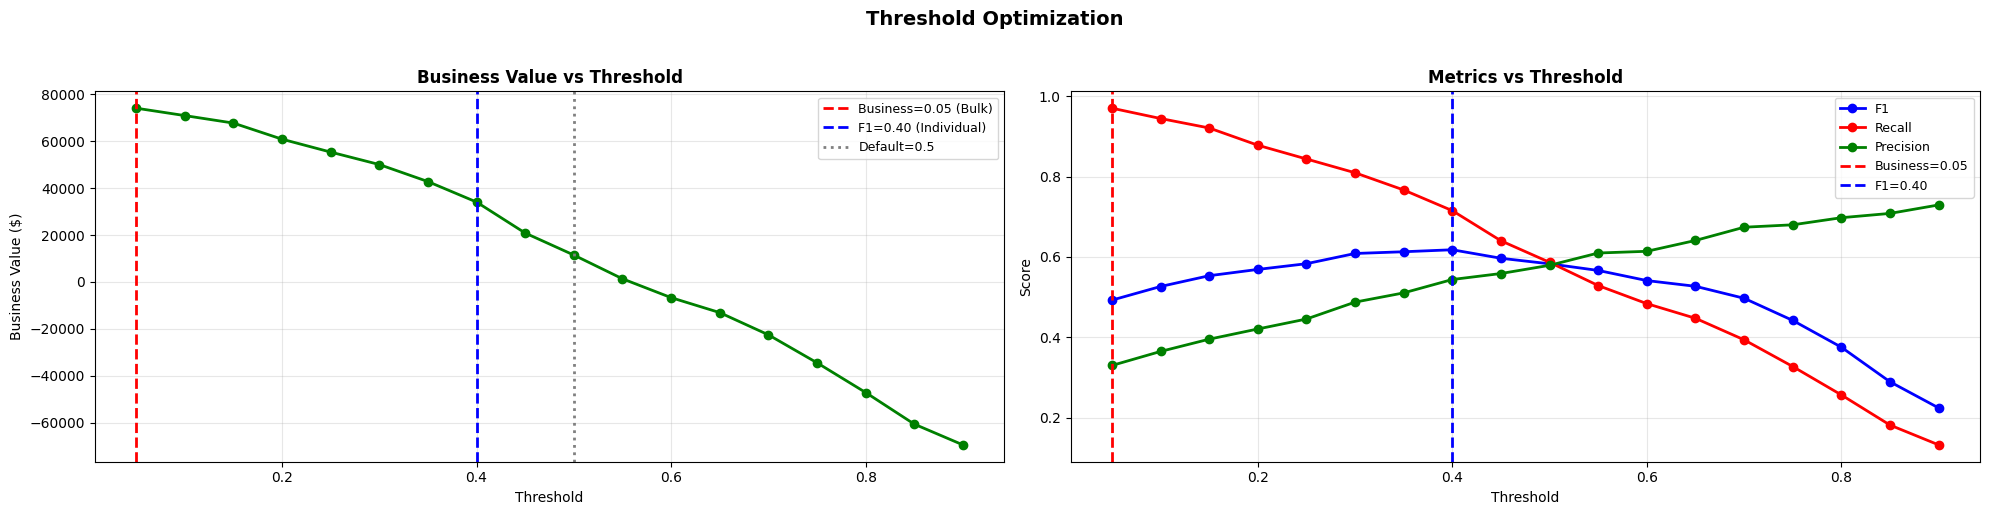

In [13]:
# STEP 13: THRESHOLD TUNING

COST_OFFER   = 10
REVENUE_SAVE = 200

best_probs   = best_rf_tuned.predict_proba(
    X_test_scaled
)[:, 1]

thresholds    = np.arange(0.05, 0.95, 0.05)
f1_scores_t   = []
business_vals = []
recall_scores = []
precision_scores = []

for t in thresholds:
    preds = (best_probs >= t).astype(int)
    cm_t  = confusion_matrix(Y_test, preds)
    tn_t  = cm_t[0][0]
    fp_t  = cm_t[0][1]
    fn_t  = cm_t[1][0]
    tp_t  = cm_t[1][1]

    f1_scores_t.append(
        f1_score(Y_test, preds, zero_division=0)
    )
    business_vals.append(
        tp_t * (REVENUE_SAVE - COST_OFFER) -
        fp_t * COST_OFFER -
        fn_t * REVENUE_SAVE
    )
    report_t = classification_report(
        Y_test, preds,
        output_dict=True, zero_division=0
    )
    recall_scores.append(report_t['1']['recall'])
    precision_scores.append(report_t['1']['precision'])

best_t_f1  = thresholds[
    f1_scores_t.index(max(f1_scores_t))
]
best_t_biz = thresholds[
    business_vals.index(max(business_vals))
]

print(f"F1-Optimized Threshold:       {best_t_f1:.2f}")
print(f"  → Use for INDIVIDUAL predictions")
print(f"Business-Optimized Threshold: {best_t_biz:.2f}")
print(f"  → Use for BULK marketing campaigns")

for t_name, t_val in [
    ('Default (0.5)',      0.5),
    ('F1 Optimized',       best_t_f1),
    ('Business Optimized', best_t_biz),
]:
    preds_t = (best_probs >= t_val).astype(int)
    cm_t    = confusion_matrix(Y_test, preds_t)
    tp_t, fp_t = cm_t[1][1], cm_t[0][1]
    fn_t, tn_t = cm_t[1][0], cm_t[0][0]
    val_t = (
        tp_t * (REVENUE_SAVE - COST_OFFER) -
        fp_t * COST_OFFER -
        fn_t * REVENUE_SAVE
    )
    f1_t  = f1_score(Y_test, preds_t, zero_division=0)
    rec_t = classification_report(
        Y_test, preds_t,
        output_dict=True, zero_division=0
    )['1']['recall']
    print(f"\n{t_name} (t={t_val:.2f}):")
    print(f"  Business Value: ${val_t:,}")
    print(f"  F1:             {f1_t:.4f}")
    print(f"  Recall:         {rec_t:.4f}")
    print(f"  TP={tp_t} FP={fp_t} FN={fn_t}")

# Use business threshold for bulk campaigns
optimal_pred = (best_probs >= best_t_biz).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].plot(thresholds, business_vals,
             'g-o', linewidth=2, markersize=6)
axes[0].axvline(x=best_t_biz, color='red',
                linestyle='--', linewidth=2,
                label=f'Business={best_t_biz:.2f} (Bulk)')
axes[0].axvline(x=best_t_f1, color='blue',
                linestyle='--', linewidth=2,
                label=f'F1={best_t_f1:.2f} (Individual)')
axes[0].axvline(x=0.5, color='gray',
                linestyle=':', linewidth=2,
                label='Default=0.5')
axes[0].set_title('Business Value vs Threshold',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Threshold', fontsize=10)
axes[0].set_ylabel('Business Value ($)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_scores_t,
             'b-o', linewidth=2, label='F1')
axes[1].plot(thresholds, recall_scores,
             'r-o', linewidth=2, label='Recall')
axes[1].plot(thresholds, precision_scores,
             'g-o', linewidth=2, label='Precision')
axes[1].axvline(x=best_t_biz, color='red',
                linestyle='--', linewidth=2,
                label=f'Business={best_t_biz:.2f}')
axes[1].axvline(x=best_t_f1, color='blue',
                linestyle='--', linewidth=2,
                label=f'F1={best_t_f1:.2f}')
axes[1].set_title('Metrics vs Threshold',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Threshold', fontsize=10)
axes[1].set_ylabel('Score', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Threshold Optimization',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Calculating SHAP values...
Format: 3D array
Shape: (500, 37)

Top 15 Features by SHAP Value:
                       Feature  SHAP_Value
                        tenure    0.051588
   internetservice_Fiber optic    0.051024
             contract_Two year    0.050267
paymentmethod_Electronic check    0.042049
            tenure_group_Short    0.031100
          paperlessbilling_Yes    0.027572
             contract_One year    0.027130
            onlinesecurity_Yes    0.024635
                  totalcharges    0.021826
               techsupport_Yes    0.021714
                monthlycharges    0.019832
              new_high_charges    0.017975
                 charges_ratio    0.016354
             multiplelines_Yes    0.013341
                dependents_Yes    0.010795


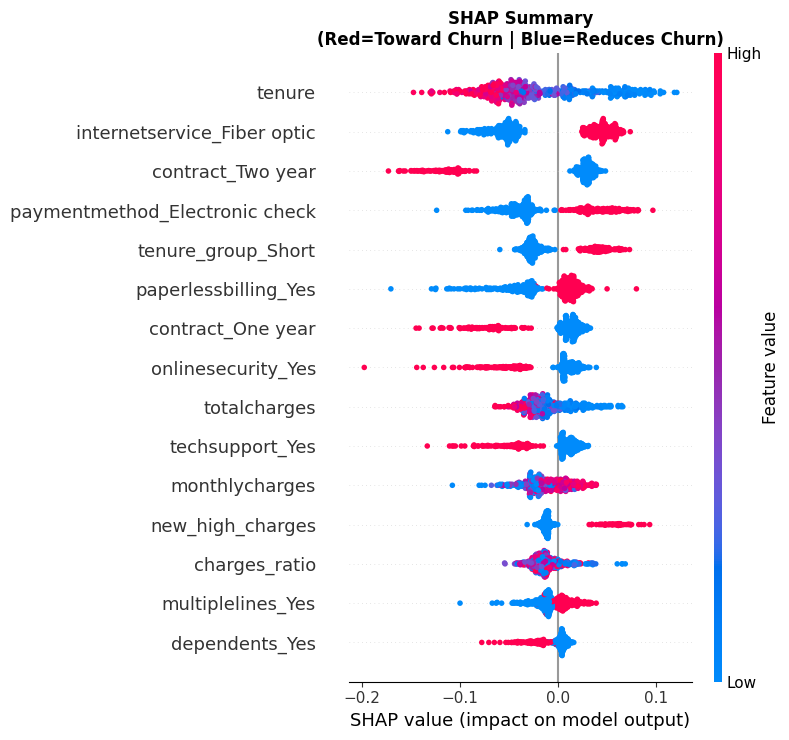

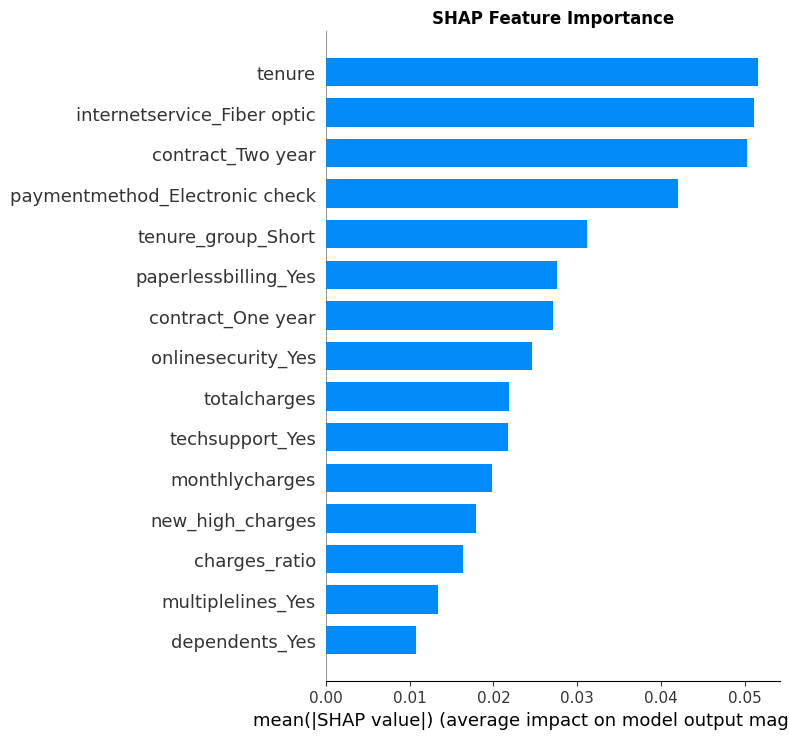

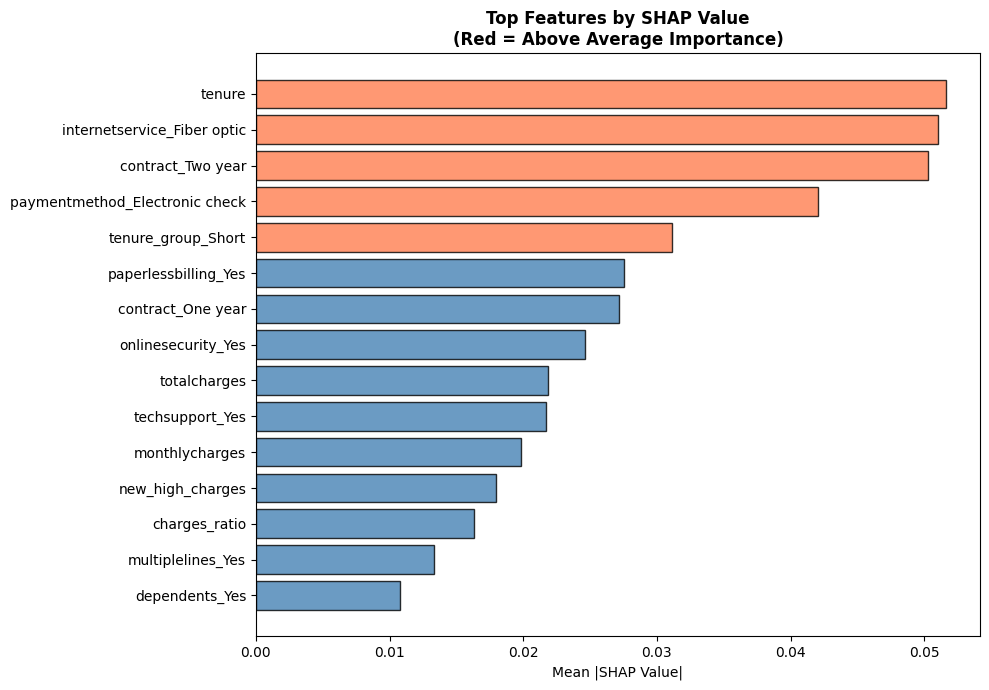

In [14]:
# STEP 14: SHAP VALUES

sample_size   = min(500, X_test_scaled.shape[0])
X_sample      = X_test_scaled[:sample_size]

print("Calculating SHAP values...")
explainer_imp = shap.TreeExplainer(best_rf_tuned)
shap_values   = explainer_imp.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_churn = shap_values[1]
    print("Format: list")
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_churn = shap_values[:, :, 1]
    print("Format: 3D array")
else:
    shap_churn = shap_values
    print("Format: 2D array")

print(f"Shape: {shap_churn.shape}")

feature_names = X.columns.tolist()
mean_shap     = np.abs(shap_churn).mean(axis=0).flatten()

shap_df = pd.DataFrame({
    'Feature':    feature_names,
    'SHAP_Value': mean_shap
}).sort_values('SHAP_Value', ascending=False).head(15)

print("\nTop 15 Features by SHAP Value:")
print(shap_df.to_string(index=False))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_churn, X_sample,
    feature_names=feature_names,
    show=False, max_display=15
)
plt.title(
    'SHAP Summary\n(Red=Toward Churn | Blue=Reduces Churn)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/content/shap_summary.png',
            bbox_inches='tight', dpi=100)
plt.show()
plt.close()

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_churn, X_sample,
    feature_names=feature_names,
    plot_type='bar', show=False, max_display=15
)
plt.title('SHAP Feature Importance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/shap_importance.png',
            bbox_inches='tight', dpi=100)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['coral' if v > shap_df['SHAP_Value'].mean()
           else 'steelblue'
           for v in shap_df['SHAP_Value']]
ax.barh(
    shap_df['Feature'],
    shap_df['SHAP_Value'],
    color=colors, edgecolor='black', alpha=0.8
)
ax.set_title('Top Features by SHAP Value\n'
             '(Red = Above Average Importance)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# STEP 15: ENSEMBLE METHODS

print("Training Voting Ensemble...")
voting_clf = VotingClassifier(
    estimators=[
        ('lr',   LogisticRegression(
            random_state=42, max_iter=1000
        )),
        ('ada',  AdaBoostClassifier(
            n_estimators=100, random_state=42
        )),
        ('lgbm', LGBMClassifier(
            n_estimators=100, random_state=42, verbose=-1
        ))
    ],
    voting='soft'
)
voting_clf.fit(X_train_sm, Y_train_sm)

Y_pred_vote = voting_clf.predict(X_test_scaled)
Y_prob_vote = voting_clf.predict_proba(
    X_test_scaled
)[:, 1]

vote_auc = roc_auc_score(Y_test, Y_prob_vote)
vote_f1  = f1_score(Y_test, Y_pred_vote)

print(f"\nVoting Ensemble:")
print(f"  AUC: {vote_auc:.4f}")
print(f"  F1:  {vote_f1:.4f}")

print("\nTraining Stacking Ensemble...")
stack_clf = StackingClassifier(
    estimators=[
        ('lr',   LogisticRegression(
            random_state=42, max_iter=1000
        )),
        ('ada',  AdaBoostClassifier(
            n_estimators=100, random_state=42
        )),
        ('lgbm', LGBMClassifier(
            n_estimators=100, random_state=42, verbose=-1
        )),
        ('rf',   RandomForestClassifier(
            n_estimators=100, random_state=42
        ))
    ],
    final_estimator=LogisticRegression(
        random_state=42, max_iter=1000
    ),
    cv=5, n_jobs=-1
)
stack_clf.fit(X_train_sm, Y_train_sm)

Y_pred_stack = stack_clf.predict(X_test_scaled)
Y_prob_stack = stack_clf.predict_proba(
    X_test_scaled
)[:, 1]

stack_auc = roc_auc_score(Y_test, Y_prob_stack)
stack_f1  = f1_score(Y_test, Y_pred_stack)

print(f"\nStacking Ensemble:")
print(f"  AUC: {stack_auc:.4f}")
print(f"  F1:  {stack_f1:.4f}")

print(f"\nFull Comparison:")
print(f"  Best Single (LR): AUC=0.8397")
print(f"  Tuned RF:         AUC={tuned_auc:.4f}")
print(f"  Voting:           AUC={vote_auc:.4f}")
print(f"  Stacking:         AUC={stack_auc:.4f}")

best_ensemble = max([
    ('Voting',       vote_auc),
    ('Stacking',     stack_auc),
    ('Tuned RF',     tuned_auc),
    ('Logistic Reg', 0.8397),
], key=lambda x: x[1])
print(f"\nBest Overall: {best_ensemble[0]} "
      f"(AUC={best_ensemble[1]:.4f})")

Training Voting Ensemble...

Voting Ensemble:
  AUC: 0.8388
  F1:  0.6264

Training Stacking Ensemble...

Stacking Ensemble:
  AUC: 0.8202
  F1:  0.5823

Full Comparison:
  Best Single (LR): AUC=0.8397
  Tuned RF:         AUC=0.8202
  Voting:           AUC=0.8388
  Stacking:         AUC=0.8202

Best Overall: Logistic Reg (AUC=0.8397)


Generating learning curves...

Random Forest: HIGH VARIANCE (Overfitting) (gap=0.1482)

Logistic Regression: GOOD FIT (gap=0.0012)


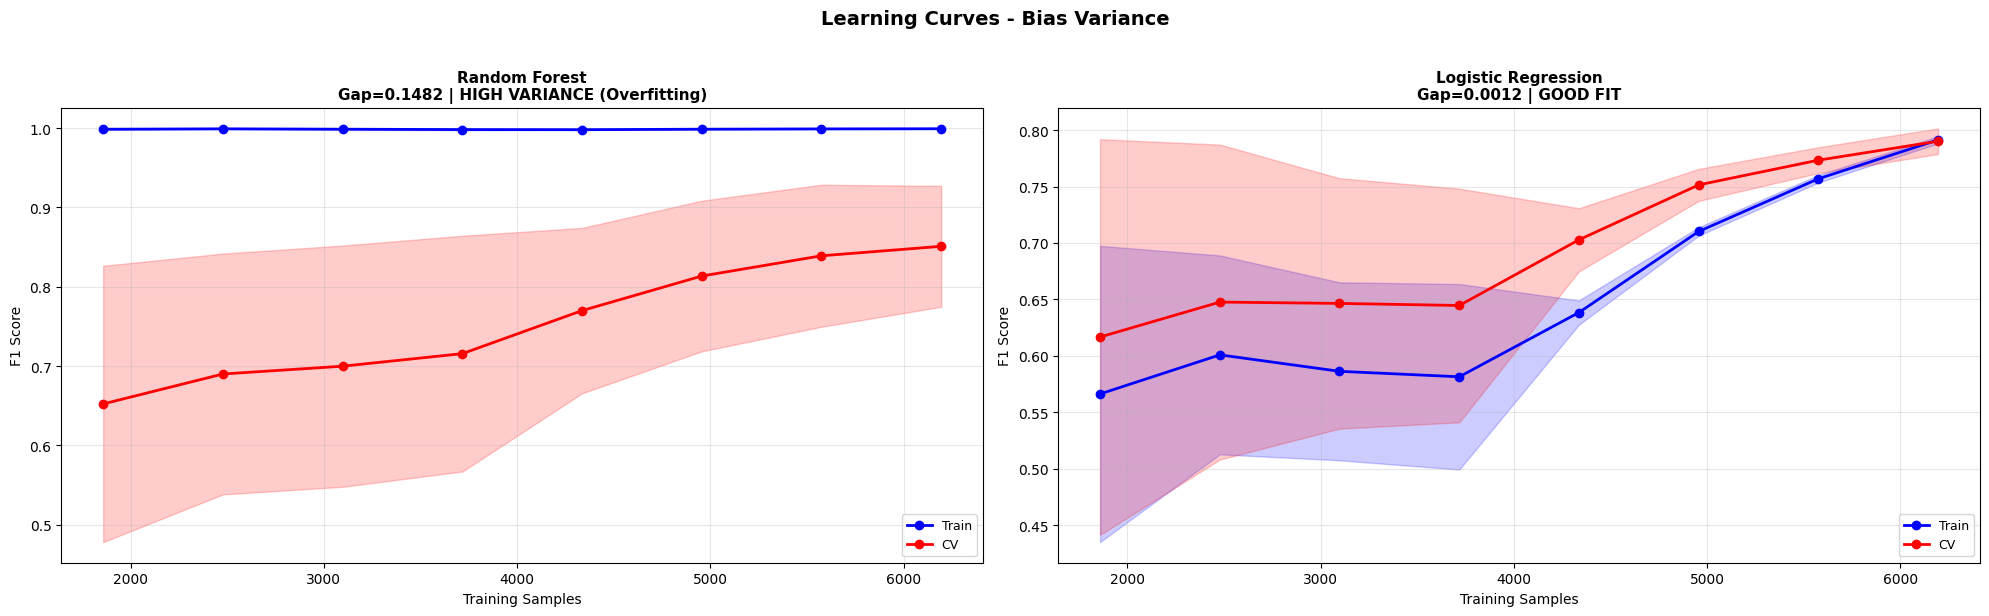

In [16]:
# STEP 16: LEARNING CURVES

print("Generating learning curves...")

tr_sz_rf, tr_sc_rf, te_sc_rf = learning_curve(
    RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    X_train_sm, Y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1', n_jobs=-1
)

tr_sz_lr, tr_sc_lr, te_sc_lr = learning_curve(
    LogisticRegression(
        random_state=42, max_iter=1000
    ),
    X_train_sm, Y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1', n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, tr_sz, tr_sc, te_sc, title in zip(
    axes,
    [tr_sz_rf, tr_sz_lr],
    [tr_sc_rf, tr_sc_lr],
    [te_sc_rf, te_sc_lr],
    ['Random Forest', 'Logistic Regression']
):
    tr_mean = tr_sc.mean(axis=1)
    tr_std  = tr_sc.std(axis=1)
    te_mean = te_sc.mean(axis=1)
    te_std  = te_sc.std(axis=1)
    gap     = tr_mean[-1] - te_mean[-1]

    ax.plot(tr_sz, tr_mean, 'b-o',
            linewidth=2, label='Train')
    ax.fill_between(tr_sz,
                    tr_mean - tr_std,
                    tr_mean + tr_std,
                    alpha=0.2, color='blue')
    ax.plot(tr_sz, te_mean, 'r-o',
            linewidth=2, label='CV')
    ax.fill_between(tr_sz,
                    te_mean - te_std,
                    te_mean + te_std,
                    alpha=0.2, color='red')

    if gap > 0.1:
        diag = 'HIGH VARIANCE (Overfitting)'
    elif tr_mean[-1] < 0.7:
        diag = 'HIGH BIAS (Underfitting)'
    else:
        diag = 'GOOD FIT'

    ax.set_title(f'{title}\nGap={gap:.4f} | {diag}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Samples', fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    print(f"\n{title}: {diag} (gap={gap:.4f})")

plt.suptitle('Learning Curves - Bias Variance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Using Business Threshold (0.05) for bulk campaign:
  TP=453 | FP=919 | FN=14 | TN=372

Business Value:
  Revenue saved:       +$86,070
  False alarm cost:     -$9,190
  Missed churner cost:  -$2,800
  NET VALUE:             $74,080

Strategy Comparison:
  Do Nothing:     $0
  Random:         $-8,990
  All Customers:  $75,820
  ML Model:       $74,080

  ML vs Random:   +$83,070


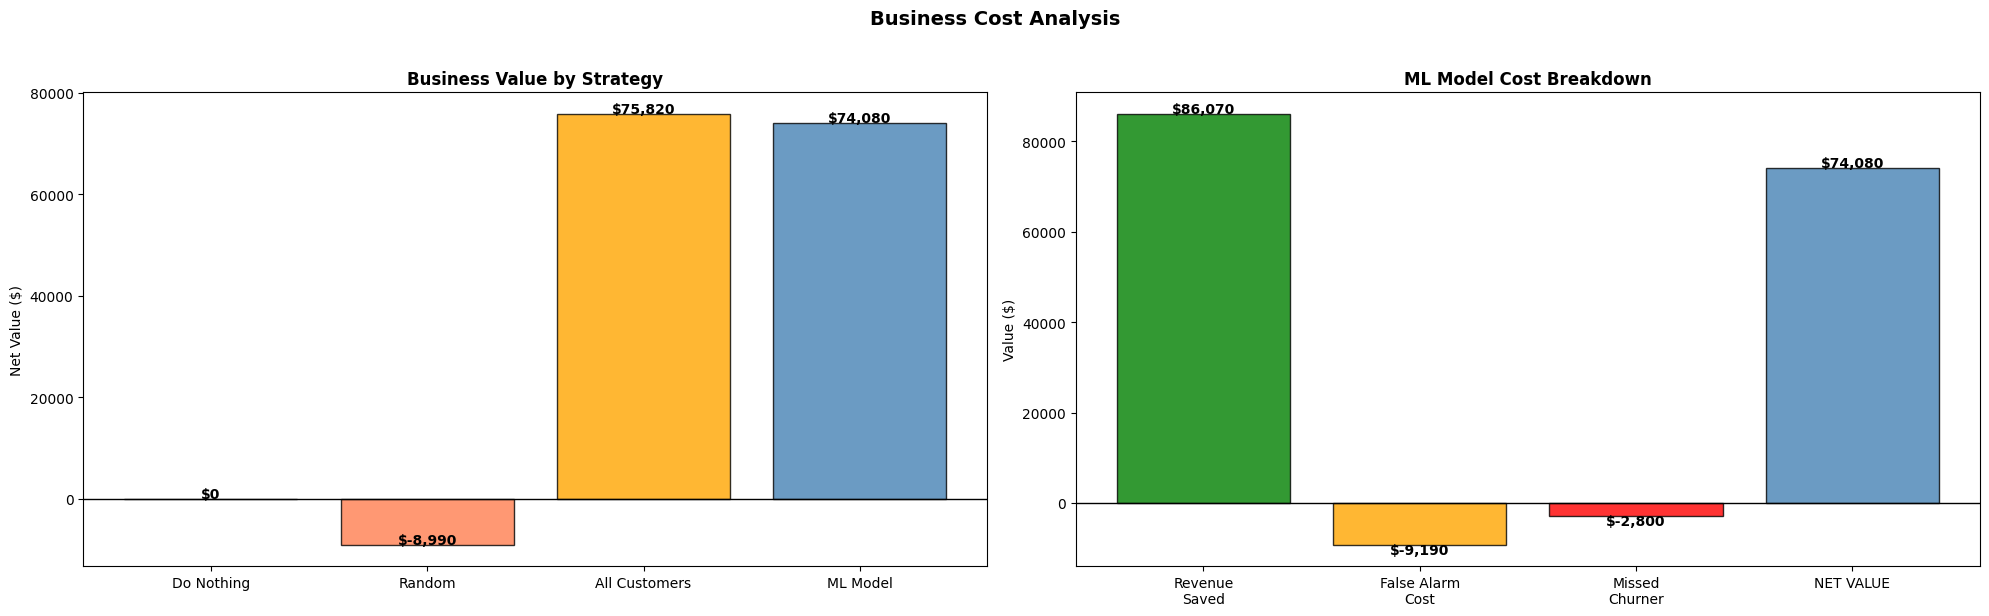

In [17]:
# STEP 17: BUSINESS COST ANALYSIS

cm_opt = confusion_matrix(Y_test, optimal_pred)
tn = cm_opt[0][0]
fp = cm_opt[0][1]
fn = cm_opt[1][0]
tp = cm_opt[1][1]

value_tp  = tp * (REVENUE_SAVE - COST_OFFER)
cost_fp   = fp * COST_OFFER
cost_fn   = fn * REVENUE_SAVE
net_value = value_tp - cost_fp - cost_fn

do_nothing   = 0
all_offers   = (
    Y_test.sum() * (REVENUE_SAVE - COST_OFFER) -
    (len(Y_test) - Y_test.sum()) * COST_OFFER
)
n_random     = len(Y_test) // 2
random_tp    = int(Y_test.sum() * 0.5)
random_fp    = n_random - random_tp
random_fn    = Y_test.sum() - random_tp
random_value = (
    random_tp * (REVENUE_SAVE - COST_OFFER) -
    random_fp * COST_OFFER -
    random_fn * REVENUE_SAVE
)

print(f"Using Business Threshold ({best_t_biz:.2f}) for bulk campaign:")
print(f"  TP={tp} | FP={fp} | FN={fn} | TN={tn}")
print(f"\nBusiness Value:")
print(f"  Revenue saved:       +${value_tp:,}")
print(f"  False alarm cost:     -${cost_fp:,}")
print(f"  Missed churner cost:  -${cost_fn:,}")
print(f"  NET VALUE:             ${net_value:,}")
print(f"\nStrategy Comparison:")
print(f"  Do Nothing:     ${do_nothing:,}")
print(f"  Random:         ${int(random_value):,}")
print(f"  All Customers:  ${int(all_offers):,}")
print(f"  ML Model:       ${net_value:,}")
print(f"\n  ML vs Random:   +${net_value - int(random_value):,}")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scenarios = ['Do Nothing', 'Random',
             'All Customers', 'ML Model']
values    = [0, int(random_value),
             int(all_offers), net_value]
bar_cols  = ['gray', 'coral', 'orange', 'steelblue']

bars = axes[0].bar(scenarios, values,
                   color=bar_cols,
                   edgecolor='black', alpha=0.8)
axes[0].set_title('Business Value by Strategy',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Net Value ($)', fontsize=10)
axes[0].axhline(y=0, color='black', linewidth=1)
for bar, v in zip(bars, values):
    ypos = bar.get_height() + 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        ypos, f'${v:,}',
        ha='center', fontsize=10, fontweight='bold'
    )

categories = ['Revenue\nSaved', 'False Alarm\nCost',
              'Missed\nChurner', 'NET VALUE']
amounts    = [value_tp, -cost_fp, -cost_fn, net_value]
cols2      = ['green', 'orange', 'red', 'steelblue']

bars2 = axes[1].bar(categories, amounts,
                    color=cols2, edgecolor='black',
                    alpha=0.8)
axes[1].set_title('ML Model Cost Breakdown',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Value ($)', fontsize=10)
axes[1].axhline(y=0, color='black', linewidth=1)
for bar, v in zip(bars2, amounts):
    ypos = v + 200 if v >= 0 else v - 2000
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        ypos, f'${v:,}',
        ha='center', fontsize=10, fontweight='bold'
    )

plt.suptitle('Business Cost Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Risk Tier Distribution:
Risk_Tier
Low Risk         983
Medium Risk      407
High Risk        196
Critical Risk    172
Name: count, dtype: int64

Churn Rate by Risk Tier:
               Churn Rate  Churners  Total
Risk_Tier                                 
Critical Risk       0.698       120    172
High Risk           0.541       106    196
Low Risk            0.091        89    983
Medium Risk         0.373       152    407


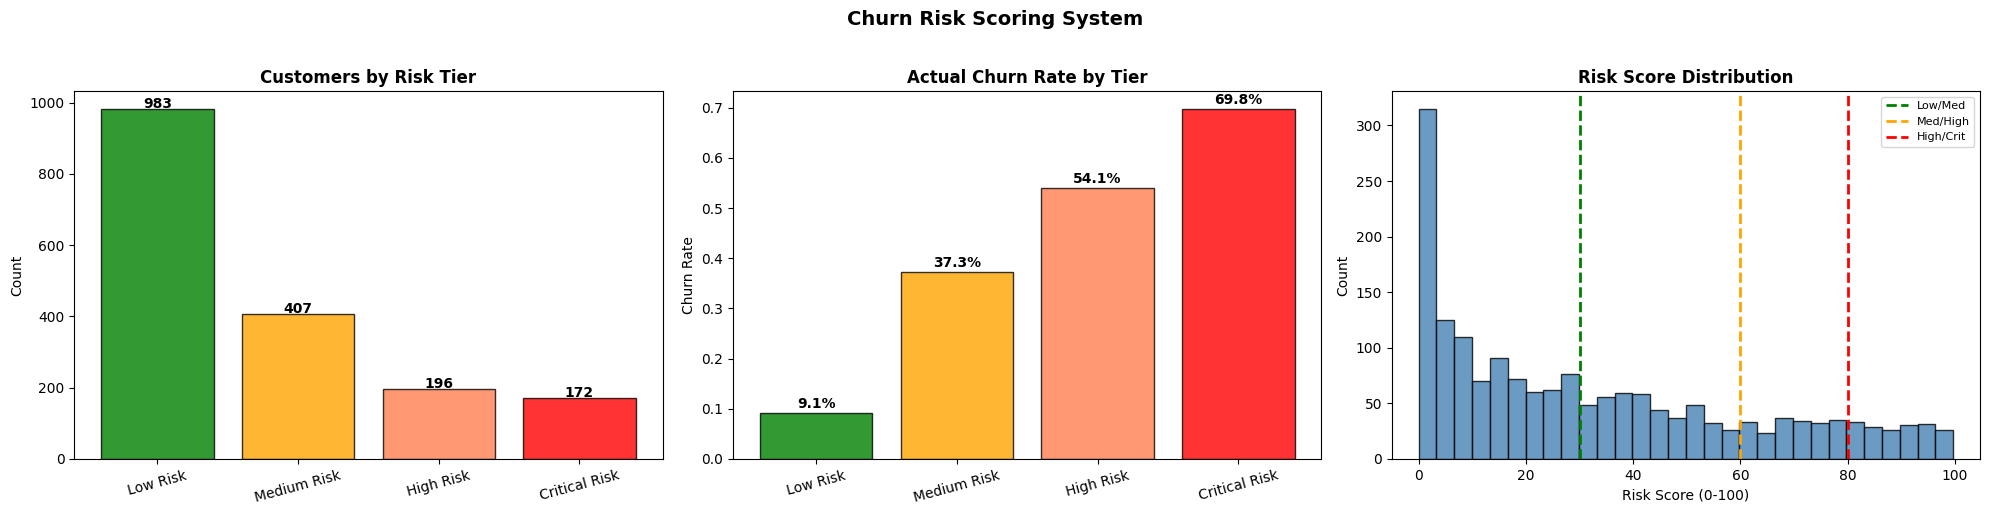

In [18]:
# STEP 18: RISK SCORING SYSTEM

risk_scores = best_rf_tuned.predict_proba(
    X_test_scaled
)[:, 1] * 100

def assign_tier(score):
    if score < 30:   return 'Low Risk'
    elif score < 60: return 'Medium Risk'
    elif score < 80: return 'High Risk'
    else:            return 'Critical Risk'

risk_df = pd.DataFrame({
    'Risk_Score':   risk_scores.round(1),
    'Risk_Tier':    [assign_tier(s) for s in risk_scores],
    'Actual_Churn': Y_test.values
})

tier_dist = risk_df['Risk_Tier'].value_counts()
print("Risk Tier Distribution:")
print(tier_dist)

print("\nChurn Rate by Risk Tier:")
churn_by_tier = risk_df.groupby('Risk_Tier')[
    'Actual_Churn'
].agg(['mean', 'sum', 'count']).round(3)
churn_by_tier.columns = ['Churn Rate', 'Churners', 'Total']
print(churn_by_tier)

tier_order  = ['Low Risk', 'Medium Risk',
               'High Risk', 'Critical Risk']
tier_colors = ['green', 'orange', 'coral', 'red']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

tier_counts = [tier_dist.get(t, 0) for t in tier_order]
axes[0].bar(tier_order, tier_counts,
            color=tier_colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Customers by Risk Tier',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tier_counts):
    axes[0].text(i, v + 2, str(v),
                 ha='center', fontsize=10,
                 fontweight='bold')

churn_rates = [
    churn_by_tier.loc[t, 'Churn Rate']
    if t in churn_by_tier.index else 0
    for t in tier_order
]
axes[1].bar(tier_order, churn_rates,
            color=tier_colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Actual Churn Rate by Tier',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(churn_rates):
    axes[1].text(i, v + 0.01, f'{v:.1%}',
                 ha='center', fontsize=10,
                 fontweight='bold')

axes[2].hist(risk_scores, bins=30,
             color='steelblue', edgecolor='black',
             alpha=0.8)
for cutoff, color, label in zip(
    [30, 60, 80],
    ['green', 'orange', 'red'],
    ['Low/Med', 'Med/High', 'High/Crit']
):
    axes[2].axvline(x=cutoff, color=color,
                    linestyle='--', linewidth=2,
                    label=label)
axes[2].set_title('Risk Score Distribution',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Risk Score (0-100)', fontsize=10)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle('Churn Risk Scoring System',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# STEP 19: RETENTION STRATEGY

strategies = {
    'Critical Risk': {
        'Action':   'Immediate personal phone call',
        'Offer':    '30% discount for 6 months',
        'Timeline': 'Within 24 hours',
        'Priority': 'URGENT'
    },
    'High Risk': {
        'Action':   'Personalized email + survey',
        'Offer':    '20% discount + free upgrade',
        'Timeline': 'Within this week',
        'Priority': 'HIGH'
    },
    'Medium Risk': {
        'Action':   'Loyalty points + check-in',
        'Offer':    'Loyalty reward points',
        'Timeline': 'This month',
        'Priority': 'MEDIUM'
    },
    'Low Risk': {
        'Action':   'Regular newsletter only',
        'Offer':    'Standard promotions',
        'Timeline': 'No urgency',
        'Priority': 'LOW'
    }
}

print("Retention Strategy by Risk Tier:")
print("="*60)
for tier in tier_order:
    if tier not in strategies:
        continue
    info  = strategies[tier]
    count = tier_dist.get(tier, 0)
    rate  = churn_by_tier.loc[
        tier, 'Churn Rate'
    ] if tier in churn_by_tier.index else 0
    print(f"\n{tier} ({count} customers | "
          f"Churn: {rate:.1%})")
    print(f"  Action:   {info['Action']}")
    print(f"  Offer:    {info['Offer']}")
    print(f"  Timeline: {info['Timeline']}")
    print(f"  Priority: {info['Priority']}")

Retention Strategy by Risk Tier:

Low Risk (983 customers | Churn: 9.1%)
  Action:   Regular newsletter only
  Offer:    Standard promotions
  Timeline: No urgency
  Priority: LOW

Medium Risk (407 customers | Churn: 37.3%)
  Action:   Loyalty points + check-in
  Offer:    Loyalty reward points
  Timeline: This month
  Priority: MEDIUM

High Risk (196 customers | Churn: 54.1%)
  Action:   Personalized email + survey
  Offer:    20% discount + free upgrade
  Timeline: Within this week
  Priority: HIGH

Critical Risk (172 customers | Churn: 69.8%)
  Action:   Immediate personal phone call
  Offer:    30% discount for 6 months
  Timeline: Within 24 hours
  Priority: URGENT


In [20]:
# STEP 20: FULL PIPELINE

full_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  RandomForestClassifier(
        n_estimators=100, random_state=42
    ))
])

full_pipeline.fit(X_train, Y_train)

Y_pred_pipe = full_pipeline.predict(X_test)
Y_prob_pipe = full_pipeline.predict_proba(X_test)[:, 1]

pipe_auc = roc_auc_score(Y_test, Y_prob_pipe)
pipe_f1  = f1_score(Y_test, Y_pred_pipe)

print(f"Pipeline Results:")
print(f"  AUC:      {pipe_auc:.4f}")
print(f"  F1:       {pipe_f1:.4f}")
print(f"  Accuracy: {accuracy_score(Y_test, Y_pred_pipe)*100:.2f}%")

Pipeline Results:
  AUC:      0.8164
  F1:       0.5801
  Accuracy: 77.93%


In [21]:
# STEP 21: PREDICTION WITH SHAP EXPLANATION

def predict_churn_full(
    gender, senior, partner, dependents,
    tenure, phone, lines, internet,
    security, backup, protection, support,
    tv, movies, contract, paperless,
    payment, monthly, total,
    threshold=best_t_f1
):
    """
    Complete churn prediction with SHAP explanation.

    Parameters: All 19 customer feature values
    threshold:  Default = F1-optimized (0.40)
                For individual predictions this gives
                correct and intuitive results.

    Returns: Prediction report with risk tier,
             SHAP explanation, CLV and action.
    """
    customer = pd.DataFrame([{
        'gender':           gender,
        'seniorcitizen':    senior,
        'partner':          partner,
        'dependents':       dependents,
        'tenure':           tenure,
        'phoneservice':     phone,
        'multiplelines':    lines,
        'internetservice':  internet,
        'onlinesecurity':   security,
        'onlinebackup':     backup,
        'deviceprotection': protection,
        'techsupport':      support,
        'streamingtv':      tv,
        'streamingmovies':  movies,
        'contract':         contract,
        'paperlessbilling': paperless,
        'paymentmethod':    payment,
        'monthlycharges':   monthly,
        'totalcharges':     total
    }])

    cat_c    = customer.select_dtypes(
        include='object'
    ).columns.tolist()
    cust_enc = pd.get_dummies(
        customer, columns=cat_c, drop_first=True
    )
    cust_enc = cust_enc.reindex(
        columns=X.columns, fill_value=0
    )
    cust_sc  = sc.transform(cust_enc)

    prob       = best_rf_tuned.predict_proba(cust_sc)[0][1]
    prediction = int(prob >= threshold)
    risk_score = prob * 100

    if risk_score < 30:   tier = 'Low Risk'
    elif risk_score < 60: tier = 'Medium Risk'
    elif risk_score < 80: tier = 'High Risk'
    else:                 tier = 'Critical Risk'

    # SHAP explanation
    shap_e = explainer_imp.shap_values(cust_sc)
    if isinstance(shap_e, list):
        shap_c = shap_e[1][0]
    elif np.array(shap_e).ndim == 3:
        shap_c = np.array(shap_e)[0, :, 1]
    else:
        shap_c = np.array(shap_e)[0]

    shap_s      = pd.Series(
        shap_c.flatten(), index=X.columns.tolist()
    )
    top_risk    = shap_s.nlargest(5)
    top_protect = shap_s.nsmallest(3)

    clv           = monthly * 24
    retention_val = clv * prob

    strat = strategies.get(tier, strategies['Low Risk'])

    print("\n" + "="*55)
    print("CHURN PREDICTION REPORT")
    print("="*55)
    print(f"Prediction:   "
          f"{'WILL CHURN' if prediction else 'WILL STAY'}")
    print(f"Churn Prob:   {prob*100:.1f}%")
    print(f"Risk Score:   {risk_score:.1f} / 100")
    print(f"Risk Tier:    {tier}")
    print(f"Threshold:    {threshold:.2f} (F1-optimized)")

    print(f"\nTop 5 Churn Risk Factors:")
    for feat, val in top_risk.items():
        print(f"  + {feat.replace('_',' ').title():<32}"
              f"({val:+.4f})")

    print(f"\nTop 3 Protective Factors:")
    for feat, val in top_protect.items():
        print(f"  - {feat.replace('_',' ').title():<32}"
              f"({val:+.4f})")

    print(f"\nBusiness Value:")
    print(f"  CLV (24mo):       ${clv:,.0f}")
    print(f"  Retention value:  ${retention_val:,.0f}")

    print(f"\nAction:  {strat['Action']}")
    print(f"Offer:   {strat['Offer']}")
    print("="*55)

    return {
        'prediction':  prediction,
        'probability': round(prob, 4),
        'risk_tier':   tier,
        'top_risks':   top_risk.to_dict(),
        'action':      strat['Action'],
        'clv':         clv
    }

# Test HIGH RISK customer
print("HIGH RISK customer (new, fiber, month-to-month):")
r1 = predict_churn_full(
    gender='Female', senior=0, partner='Yes',
    dependents='No', tenure=2, phone='Yes',
    lines='No', internet='Fiber optic',
    security='No', backup='No', protection='No',
    support='No', tv='No', movies='No',
    contract='Month-to-month', paperless='Yes',
    payment='Electronic check',
    monthly=85.0, total=170.0,
    threshold=best_t_f1
)

# Test LOW RISK customer
print("\nLOW RISK customer (long tenure, 2yr contract):")
r2 = predict_churn_full(
    gender='Male', senior=0, partner='Yes',
    dependents='Yes', tenure=48, phone='Yes',
    lines='Yes', internet='DSL',
    security='Yes', backup='Yes', protection='Yes',
    support='Yes', tv='No', movies='No',
    contract='Two year', paperless='No',
    payment='Bank transfer (automatic)',
    monthly=55.0, total=2640.0,
    threshold=best_t_f1
)

# Threshold Usage Guide
print("\n" + "="*55)
print("THRESHOLD USAGE GUIDE")
print("="*55)
print(f"  Individual predictions: use {best_t_f1:.2f}")
print(f"    → Sensible Yes/No for each customer")
print(f"    → HIGH RISK → WILL CHURN")
print(f"    → LOW RISK  → WILL STAY")
print(f"\n  Bulk marketing campaigns: use {best_t_biz:.2f}")
print(f"    → Aggressive targeting")
print(f"    → Catches 97% of all churners")
print(f"    → Generates ${net_value:,} net value")
print("="*55)

HIGH RISK customer (new, fiber, month-to-month):

CHURN PREDICTION REPORT
Prediction:   WILL CHURN
Churn Prob:   46.2%
Risk Score:   46.2 / 100
Risk Tier:    Medium Risk
Threshold:    0.40 (F1-optimized)

Top 5 Churn Risk Factors:
  + Tenure                          (+0.0744)
  + Totalcharges                    (+0.0349)
  + Contract Two Year               (+0.0327)
  + Contract One Year               (+0.0150)
  + Onlinesecurity Yes              (+0.0139)

Top 3 Protective Factors:
  - Paperlessbilling Yes            (-0.0597)
  - Internetservice Fiber Optic     (-0.0543)
  - Paymentmethod Electronic Check  (-0.0417)

Business Value:
  CLV (24mo):       $2,040
  Retention value:  $942

Action:  Loyalty points + check-in
Offer:   Loyalty reward points

LOW RISK customer (long tenure, 2yr contract):

CHURN PREDICTION REPORT
Prediction:   WILL STAY
Churn Prob:   27.0%
Risk Score:   27.0 / 100
Risk Tier:    Low Risk
Threshold:    0.40 (F1-optimized)

Top 5 Churn Risk Factors:
  + Contract


## Key Results

### Model Performance

```
╔══════════════════════════════════════════════════════════╗
║  Best Model:  Logistic Regression                        ║
║  AUC Score:   0.8397  (separates classes well)           ║
║  F1 Score:    0.6194  (balance precision/recall)         ║
║  Recall:      0.7859  (catches 78.6% of churners)        ║
║  AP Score:    0.6542  (best precision-recall balance)    ║
╚══════════════════════════════════════════════════════════╝
```

### Why Logistic Regression Won

```
Random Forest had best CV F1 = 0.8598
But Learning Curve gap = 0.1482 → HIGH VARIANCE
It was memorizing training data (overfitting)

Logistic Regression CV F1 = 0.7880 (lower)
But Learning Curve gap = 0.0012 → PERFECT FIT
It generalized far better to new data

Lesson: A simpler model that generalizes well
always beats a complex model that overfits.
```

### Threshold Strategy

| Threshold | Value | Use Case | Recall |
|-----------|-------|----------|--------|
| Default | 0.50 | Standard | 58.7% |
| F1-Optimized | **0.40** | **Individual predictions** | 71.5% |
| Business-Optimized | 0.05 | Bulk campaigns | **97.0%** |

---

## Key Insights

### Insight 1: Tenure is the #1 Predictor
```
SHAP Value: 0.0516 (highest of all features)

Short tenure customers (0-12 months) churn at 47.7%
Long tenure customers (37-72 months) churn at only 11.9%

Business Action:
  Focus retention efforts on customers in first 12 months.
  Onboarding experience is critical.
  New customer discounts can lock them in early.
```

### Insight 2: Fiber Optic = High Churn Risk
```
SHAP Value: 0.0510 (2nd highest)

Fiber optic users churn significantly more
than DSL or no internet users.

This suggests:
  Fiber optic pricing may be too high
  Fiber optic service quality issues exist
  Competitors are offering better fiber deals

Business Action:
  Review fiber pricing competitiveness.
  Proactively survey fiber customers for issues.
```

### Insight 3: Contract Type is Critical
```
Two Year Contract SHAP: 0.0503 (3rd highest)

Month-to-month:  Highest churn
One year:        Medium churn
Two year:        Lowest churn

Business Action:
  Incentivize month-to-month customers
  to upgrade to annual or two-year contracts.
  Even a small discount converts them to loyal customers.
```

### Insight 4: Electronic Check = Risk Signal
```
SHAP Value: 0.0420 (4th highest)

Customers paying by electronic check churn more
than those using automatic bank transfers or credit cards.

This suggests:
  Electronic check users are less committed
  Automatic payment setup increases retention
  
Business Action:
  Offer incentive to switch to auto-pay.
  Auto-pay customers are harder to churn.
```

### Insight 5: New High Charges = Highest Risk Group
```
Customers with tenure < 12 months AND
high monthly charges churn at 69.8%
vs 26.6% overall average.

This is 2.6x the normal churn rate.
These customers feel they are not getting value.

Business Action:
  Flag these customers immediately on signup.
  Assign a dedicated account manager.
  Check in at month 1, 3, 6.
```

### Insight 6: Feature Engineering Worked
```
6 new engineered features appear in top 15 SHAP:
  tenure_group_Short  : SHAP = 0.031
  new_high_charges    : SHAP = 0.018
  charges_ratio       : SHAP = 0.016

These features were NOT in the original dataset.
We created them and they proved predictive.
AUC improved by +0.0018 after engineering.
```


## Business Impact

```
Cost Parameters:
  Retention offer cost:     $10 per customer
  Revenue saved per churn:  $200 per customer

Strategy Comparison:
  Do Nothing:          $0
  Random Outreach:     -$8,990 (negative!)
  Contact All:         $75,820
  ML Model (bulk):     $74,080

  ML vs Random:        +$83,070 improvement

The model generates nearly the same value as
contacting ALL customers but at a fraction of the cost.
It correctly identifies WHO to contact and WHY.
```


##  Risk Scoring System

| Tier | Customers | % | Actual Churn | Action |
|------|-----------|---|--------------|--------|
| 🔴 **Critical Risk** | 172 | 9.8% | **69.8%** | Immediate call + 30% discount |
| 🟠 **High Risk** | 196 | 11.1% | **54.1%** | Email + 20% discount |
| 🟡 **Medium Risk** | 407 | 23.2% | **37.3%** | Loyalty points |
| 🟢 **Low Risk** | 983 | 55.9% | **9.1%** | Newsletter only |

>  Risk tiers are validated — each tier has the expected churn rate in correct order.


##  Learning Curve Findings

| Model | Train F1 | CV F1 | Gap | Diagnosis |
|-------|----------|-------|-----|-----------|
| Random Forest | ~0.99 | ~0.85 | 0.1482 | **HIGH VARIANCE** (Overfitting) |
| Logistic Regression | ~0.79 | ~0.79 | 0.0012 | **GOOD FIT** |

> This is why Logistic Regression won despite lower cross-validation F1.
> A model that generalizes is always better than one that memorizes.

